# Homework 2
## De Simone Guido
### Introduction

In questo homework l'obiettivo è classificare correttamente delle immagini utilizzando una rete neurale costuita da zero ed una rete pre addestrata, effettuando del fine tuning.

Per prima cosa montiamo il nostro Google Drive così da poter caricare il file su Colab.

In [ ]:
# Montiamo il Google Drive
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Possiamo, ora che il Drive è collegato a Colab, espandere la cartella contenente le immagini che ci serviranno.

In [ ]:
# Espandiamo la cartella 'TRE CLASSI'
import numpy as np
!unzip /content/drive/MyDrive/Homework2/Treclassi.zip

A questo punto possiamo iniziare a lavorare, quindi come prima cosa importiamo tutte le librerie che ci serviranno poi nella costruzione della rete neurale.

In [ ]:
# Importiamo le librerie
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.applications.inception_v3 import InceptionV3, preprocess_input
import matplotlib.pyplot as plt

Effettuiamo il Data Augmentation, il quale modifica le immagini già presenti. Esso è fondamentale per aumentare la quatità e la diversità dei dati che la nostra rete neurale userà per addestrarsi, senza però raccogliere realmente nuovi dati.

In [ ]:
# Definiamo la pipeline per il pre-processing delle immagini
image_generator = ImageDataGenerator(rescale=1./255, validation_split=0.2, horizontal_flip=True, rotation_range=30,
                                     width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,)

# Carichiamo e generiamo i dati di training
train_data_gen = image_generator.flow_from_directory(
    'TRE CLASSI', target_size=(299, 299), batch_size=32, color_mode='rgb', shuffle=True,
    class_mode='categorical', subset='training')

# Carichiamo e generiamo i dati di validazione
val_data_gen = image_generator.flow_from_directory(
    'TRE CLASSI', target_size=(299, 299), batch_size=32, color_mode='rgb', shuffle=False,
    class_mode='categorical', subset='validation')

Found 2144 images belonging to 3 classes.
Found 535 images belonging to 3 classes.


A questo punto, plottiamo delle immagini appartenenti a una delle tre diverse categorie.

In [ ]:
vocab = ['Brown bears', 'Carps', 'Dogs']

In [ ]:
im1 = val_data_gen[0]
print(im1[0].shape)
print(im1[1].shape)

(32, 299, 299, 3)
(32, 3)


The selected animal (validation set) is: Brown bears


<function matplotlib.pyplot.show(close=None, block=None)>

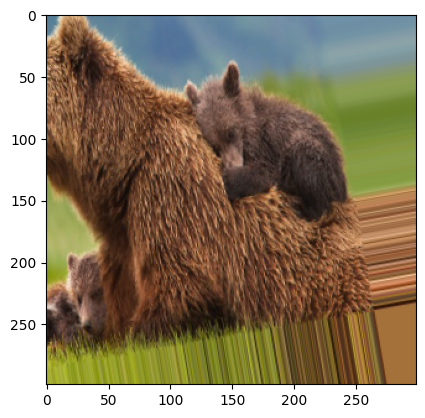

In [ ]:
%matplotlib inline
print('The selected animal (validation set) is:', vocab[np.argmax(im1[1])])
plt.imshow((im1[0][0,:,:,:]), alpha=1)
plt.show

Definiamo quindi la nostra rete neurale e addestriamo il modello. Nel primo strato di unput definiamo la dimensione dell'immagine ed il canale, nel nostro caso quest'ultimo è pari a 3, essendo le immagini a colori. Ho optato poi per la creazione di 6 strati convoluzionali, tutti regolarizzati dalla 'BatchNormalization', che ha lo scopo di effettuare la standardizzazione. Il DropOut, che ho usato anche qui per ridurre l'overfitting del modello, è stato impostato solo su alcuni strati convoluzionali ed è stato utilizzato anche dopo lo strato denso. Per quanto riguarda invece la scelta dei filtri, ho ritenuto ottimale avere un andamento crescente, corrispondente al doppio dei filtri dello strato precedente; tutti i filtri sono 3 X 3. Come funzione di attivazione ho optato per una 'relu' ed ho posto il padding come 'same', così da perdere meno informazioni possibili. Infine nello strato denso ho posto 64 neuroni in quanto con un numero maggiore il modello sviluppava troppi parametri mentre con un numero minore perdeva troppo di complessità.

In [ ]:
# Definiamo l'input della rete
input = Input(shape=(299,299,3))

# Aggiungiamo layer convoluzionali e di pooling, oltre che di regolarizzazione
x = Conv2D(8, (3, 3), activation='relu', padding='same')(input)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Aggiungiamo layer completamente connessi per la classificazione
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)  # 3 classi: cani, carpe, orsi bruni

# Creiamo il modello utilizzando la Functional API di Keras
model = Model(inputs=input, outputs=output)

# Compiliamo il modello
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Riassunto struttura del modello
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 299, 299, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 299, 299, 8)       224       
                                                                 
 max_pooling2d (MaxPooling2  (None, 149, 149, 8)       0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 149, 149, 8)       32        
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 149, 149, 16)      1168      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 74, 74, 16)        0     

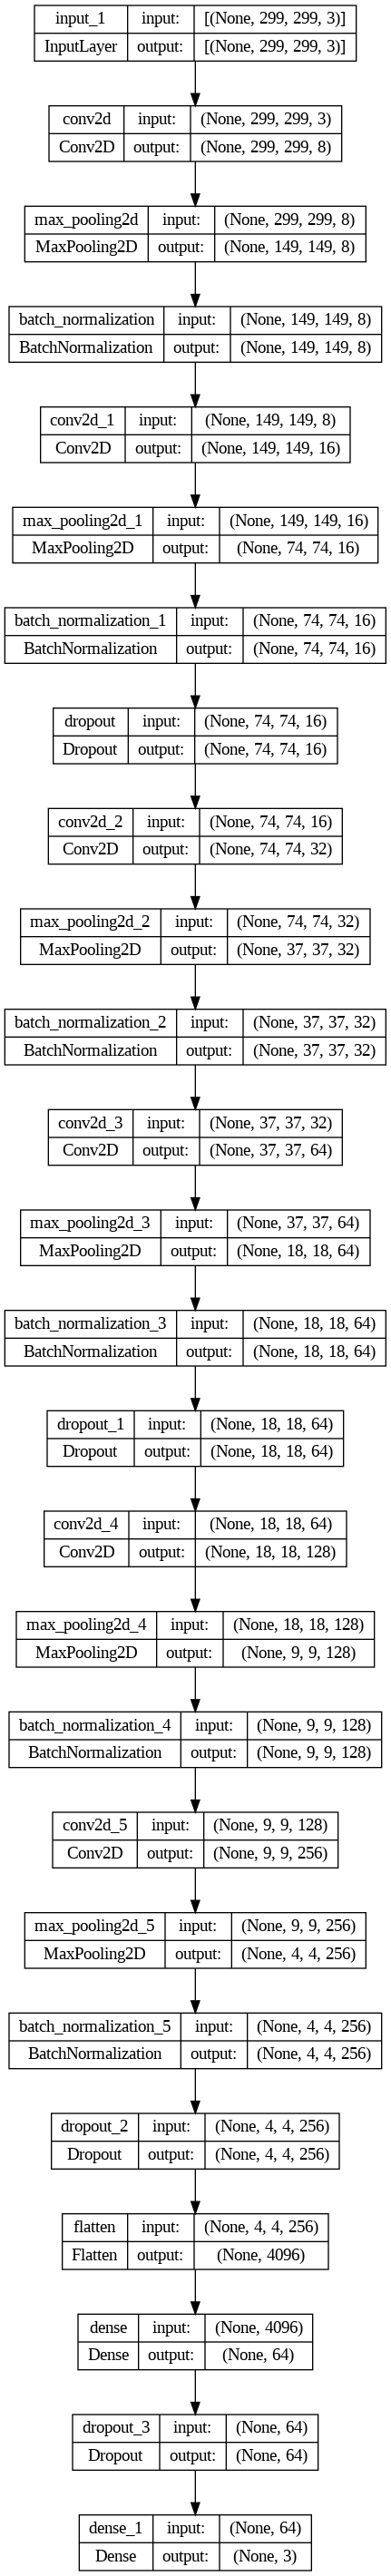

In [ ]:
# Plottiamo la struttura del modello
plot_model(model, show_shapes=True)

Per l'addestramento del modello ho ritenuto opportuno porre un numero di epoche abbastanza elevato, pari infatti a 50 (anche se il tempo di esecuzione si è rivelato essere abbastanza lungo). Questo ha permesso al modello di accrescere maggiormente l'accuracy. Nei dati di validation poi possiamo notare come l'accuracy non abbiamo un andamento del tutto costante, segno che magari avrebbe dovuto continuare ancora l'addrestamento o sarebbe stata opportuna una maggiore regolarizzazione. In ogni caso ho lasciato i valori che si possono notare sotto.

In [ ]:
# Addestriamo il modello
history = model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // train_data_gen.batch_size,
    epochs=50,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // val_data_gen.batch_size
)

Epoch 1/50
67/67 [==============================] - 84s 1s/step - loss: 1.5018 - accuracy: 0.5019 - val_loss: 1.5207 - val_accuracy: 0.3008
Epoch 2/50
67/67 [==============================] - 72s 1s/step - loss: 0.9128 - accuracy: 0.6110 - val_loss: 2.5249 - val_accuracy: 0.2969
Epoch 3/50
67/67 [==============================] - 65s 972ms/step - loss: 0.7700 - accuracy: 0.6712 - val_loss: 3.9068 - val_accuracy: 0.3027
Epoch 4/50
67/67 [==============================] - 64s 955ms/step - loss: 0.7449 - accuracy: 0.6931 - val_loss: 2.4610 - val_accuracy: 0.3281
Epoch 5/50
67/67 [==============================] - 65s 959ms/step - loss: 0.6654 - accuracy: 0.7234 - val_loss: 2.3220 - val_accuracy: 0.3574
Epoch 6/50
67/67 [==============================] - 63s 945ms/step - loss: 0.6359 - accuracy: 0.7411 - val_loss: 2.4093 - val_accuracy: 0.4707
Epoch 7/50
67/67 [==============================] - 73s 1s/step - loss: 0.5781 - accuracy: 0.7738 - val_loss: 1.2252 - val_accuracy: 0.6289
Epoch 8/

A questo punto possiamo procedere alla valutazione del modello e alla creazione della matrice di confusione.

In [ ]:
#Valutiamo il modello
score=model.evaluate(val_data_gen)
print(model.metrics_names, score)

17/17 [==============================] - 13s 765ms/step - loss: 0.4168 - accuracy: 0.8991
['loss', 'accuracy'] [0.4168347120285034, 0.8990654349327087]


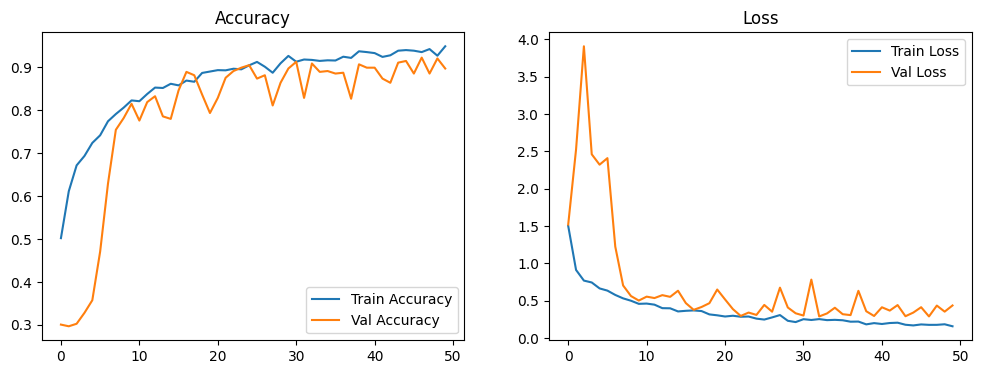

In [ ]:
# Plottiamo la curva 'loss' e 'accuracy' per vederne l'andamento in modo più intuitivo.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

17/17 [==============================] - 13s 744ms/step


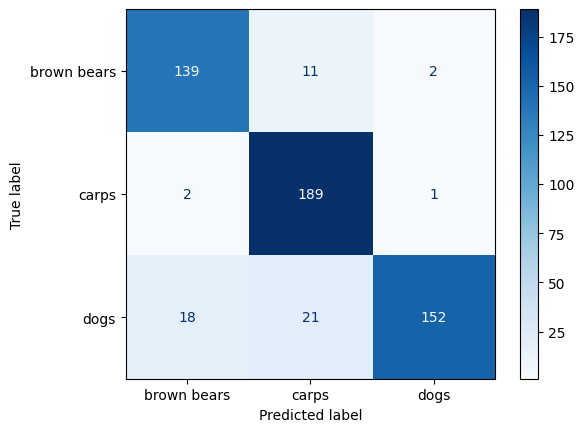

In [ ]:
#Calcolo della matrice della confusione

# Prevediamo le etichette nel validation set
val_data_gen.reset()
y_pred_cnn = model.predict(val_data_gen)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_cnn = val_data_gen.classes

# Calcoliamo la matrice di confusione
cm_cnn = confusion_matrix(y_true_cnn, y_pred_classes_cnn)

#Plottiamo matrice di confusione
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=val_data_gen.class_indices)
disp_cnn.plot(cmap=plt.cm.Blues)
plt.show()

La matrice sopra esposta si legge nel seguente modo:
Sull'asse delle X abbiamo ciò che il nostro modello ha predetto, su quello delle Y abbiamo invece ciò che l'immagine rappresenta realmente. I valori corretti sono quindi indicati dalla diagonale principale mentre gli errori sono rappresentati dagli altri quadrati.

Procediamo ora ad utilizzare per la nostra classificazione un modello pre-addestrato. Quello che useremo è il modello 'InceptionV3'.

In [ ]:
#Costruiamo il modello Inception V3
base_model = InceptionV3(include_top=False, weights='imagenet', input_tensor=Input(shape=(299, 299, 3)))

87910968/87910968 [==============================] - 1s 0us/step


In [ ]:
# Aggiungiamo nuovi livelli di classificazione sopra a quelli del modello base
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

inception_model = Model(inputs=base_model.input, outputs=output)

inception_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d_6 (Conv2D)           (None, 149, 149, 32)         864       ['input_2[0][0]']             
                                                                                                  
 batch_normalization_6 (Bat  (None, 149, 149, 32)         96        ['conv2d_6[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 activation (Activation)     (None, 149, 149, 32)         0         ['batch_normalization_6[

In [ ]:
#Stampiamo i layer a disposizione
for i, layer in enumerate(inception_model.layers):
  print(i, layer.name)

0 input_2
1 conv2d_6
2 batch_normalization_6
3 activation
4 conv2d_7
5 batch_normalization_7
6 activation_1
7 conv2d_8
8 batch_normalization_8
9 activation_2
10 max_pooling2d_6
11 conv2d_9
12 batch_normalization_9
13 activation_3
14 conv2d_10
15 batch_normalization_10
16 activation_4
17 max_pooling2d_7
18 conv2d_14
19 batch_normalization_14
20 activation_8
21 conv2d_12
22 conv2d_15
23 batch_normalization_12
24 batch_normalization_15
25 activation_6
26 activation_9
27 average_pooling2d
28 conv2d_11
29 conv2d_13
30 conv2d_16
31 conv2d_17
32 batch_normalization_11
33 batch_normalization_13
34 batch_normalization_16
35 batch_normalization_17
36 activation_5
37 activation_7
38 activation_10
39 activation_11
40 mixed0
41 conv2d_21
42 batch_normalization_21
43 activation_15
44 conv2d_19
45 conv2d_22
46 batch_normalization_19
47 batch_normalization_22
48 activation_13
49 activation_16
50 average_pooling2d_1
51 conv2d_18
52 conv2d_20
53 conv2d_23
54 conv2d_24
55 batch_normalization_18
56 batch_

In [ ]:
#Congeliamo gli strati del modello e alleniamo solo gli ultimi
for layer in base_model.layers:
    layer.trainable = False

#Compiliamo il modello
inception_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Fittiamo il modello
history_inception = inception_model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // train_data_gen.batch_size,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // val_data_gen.batch_size,
    epochs=10,
)

Epoch 1/10
67/67 [==============================] - 83s 1s/step - loss: 0.0978 - accuracy: 0.9664 - val_loss: 0.0951 - val_accuracy: 0.9707
Epoch 2/10
67/67 [==============================] - 73s 1s/step - loss: 0.0285 - accuracy: 0.9930 - val_loss: 0.0193 - val_accuracy: 0.9941
Epoch 3/10
67/67 [==============================] - 72s 1s/step - loss: 0.0191 - accuracy: 0.9930 - val_loss: 0.0499 - val_accuracy: 0.9863
Epoch 4/10
67/67 [==============================] - 73s 1s/step - loss: 0.0179 - accuracy: 0.9944 - val_loss: 0.0278 - val_accuracy: 0.9941
Epoch 5/10
67/67 [==============================] - 74s 1s/step - loss: 0.0284 - accuracy: 0.9930 - val_loss: 0.0289 - val_accuracy: 0.9902
Epoch 6/10
67/67 [==============================] - 75s 1s/step - loss: 0.0197 - accuracy: 0.9939 - val_loss: 0.0413 - val_accuracy: 0.9902
Epoch 7/10
67/67 [==============================] - 71s 1s/step - loss: 0.0328 - accuracy: 0.9902 - val_loss: 0.0287 - val_accuracy: 0.9941
Epoch 8/10
67/67 [==

Qui possiamo da subito notare la prima differenza con il nostro modello, infatti l'accuracy presenta dei valori molto alti ed il suo andamento è molto più lineare (quest'ultima parte si potrà notare meglio nel plotting delle curve di accuracy e di loss).

In [ ]:
# A questo punto effettuiamo il fine tuning continuando l'addestramento ma utilizzando anche gli strati oltre
# il 250-mo del modello base.
for layer in base_model.layers[:250]:
    layer.trainable = False
for layer in base_model.layers[250:]:
    layer.trainable = True

#Compiliamo il modello
inception_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Fittiamo il modello
history_inception = inception_model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // train_data_gen.batch_size,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // val_data_gen.batch_size,
    epochs=5,
)

Epoch 1/5
67/67 [==============================] - 109s 1s/step - loss: 0.0230 - accuracy: 0.9958 - val_loss: 9.6926 - val_accuracy: 0.6719
Epoch 2/5
67/67 [==============================] - 76s 1s/step - loss: 0.0373 - accuracy: 0.9935 - val_loss: 0.2088 - val_accuracy: 0.9824
Epoch 3/5
67/67 [==============================] - 75s 1s/step - loss: 0.0238 - accuracy: 0.9939 - val_loss: 0.1265 - val_accuracy: 0.9863
Epoch 4/5
67/67 [==============================] - 74s 1s/step - loss: 0.0042 - accuracy: 0.9986 - val_loss: 0.0617 - val_accuracy: 0.9922
Epoch 5/5
67/67 [==============================] - 76s 1s/step - loss: 0.0044 - accuracy: 0.9981 - val_loss: 0.0433 - val_accuracy: 0.9941


A questo punto, come per il modello creato da noi, possiamo procedere alla valutazione del modello e al calcolo della matrice di confusione.

In [ ]:
#Valutiamo il modello
score=inception_model.evaluate(val_data_gen)
print(inception_model.metrics_names, score)

17/17 [==============================] - 18s 1s/step - loss: 0.0703 - accuracy: 0.9907
['loss', 'accuracy'] [0.07034660130739212, 0.9906542301177979]


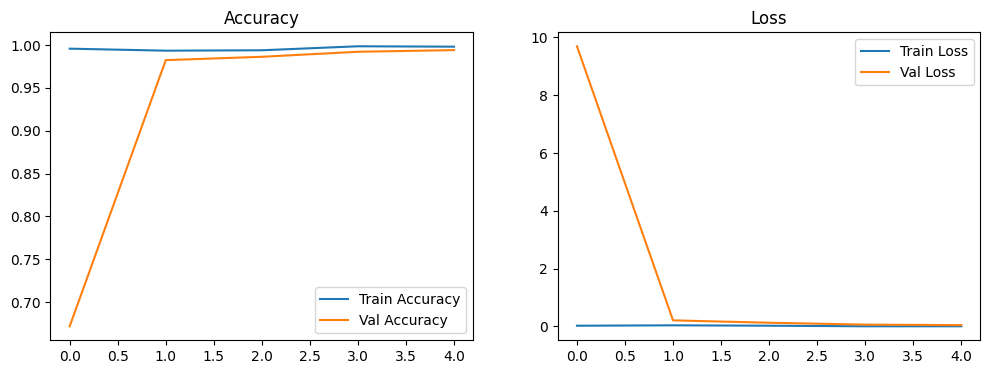

In [ ]:
#Plottiamo l'accuratezza e la loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_inception.history['accuracy'], label='Train Accuracy')
plt.plot(history_inception.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_inception.history['loss'], label='Train Loss')
plt.plot(history_inception.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

17/17 [==============================] - 15s 822ms/step


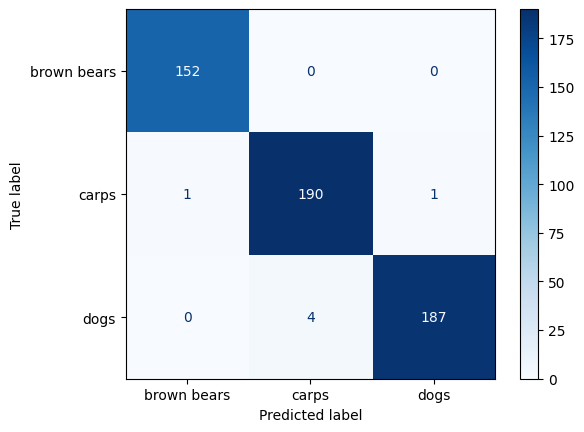

In [ ]:
#Calcolo della matrice di confusione.

# Prevedere le etichette nel validation set con il modello InceptionV3
val_data_gen.reset()
y_pred_inception = inception_model.predict(val_data_gen)
y_pred_classes_inception = np.argmax(y_pred_inception, axis=1)
y_true_inception = val_data_gen.classes

# Calcolare la matrice di confusione
cm_inception = confusion_matrix(y_true_inception, y_pred_classes_inception)
disp_inception = ConfusionMatrixDisplay(confusion_matrix=cm_inception, display_labels=val_data_gen.class_indices)
disp_inception.plot(cmap=plt.cm.Blues)
plt.show()

In conclusione, guardando la matrice di confusione, si nota a colpo d'occhio la differenza. Il modello 'InceptionV3' esegue una più che ottima classificazione, sicuramente superiore a quello ottenuta dal modello cnn da me creato.